# 04. Kundensegmentierung (K-Means Clustering)

## **Ziel des Notebooks**
In diesem Notebook führen wir das unüberwachte Machine Learning (K-Means Clustering) durch, um unsere 5.998 Aktivkunden in verhaltenshomogene Segmente zu unterteilen. Diese Segmente bilden die operative Grundlage für das neue TravelTide-Belohnungsprogramm.

---

## **Kernaktivitäten & Durchführung**

1. **Daten importieren:** Laden der skalierten (`traveltide_features_scaled.csv`) und unskalierten (`traveltide_features_unscaled.csv`) Datensätze.
2. **Optimales K bestimmen:** Anwendung der **Ellbogen-Methode (Elbow Method)** und Berechnung des **Silhouette-Scores**, um die ideale Clusteranzahl $K$ zu ermitteln.
3. **Modellierung:** Training des K-Means-Modells mit der gewählten Clusteranzahl und Zuweisung der Cluster-Labels zu allen Nutzern.
4. **Profilierung & Business-Interpretation:** Auswertung der Cluster-Mittelwerte auf den unskalierten Daten zur Definition konkreter Personas (z. B. Bargain Hunter, Business Traveler, Family Vacationer).

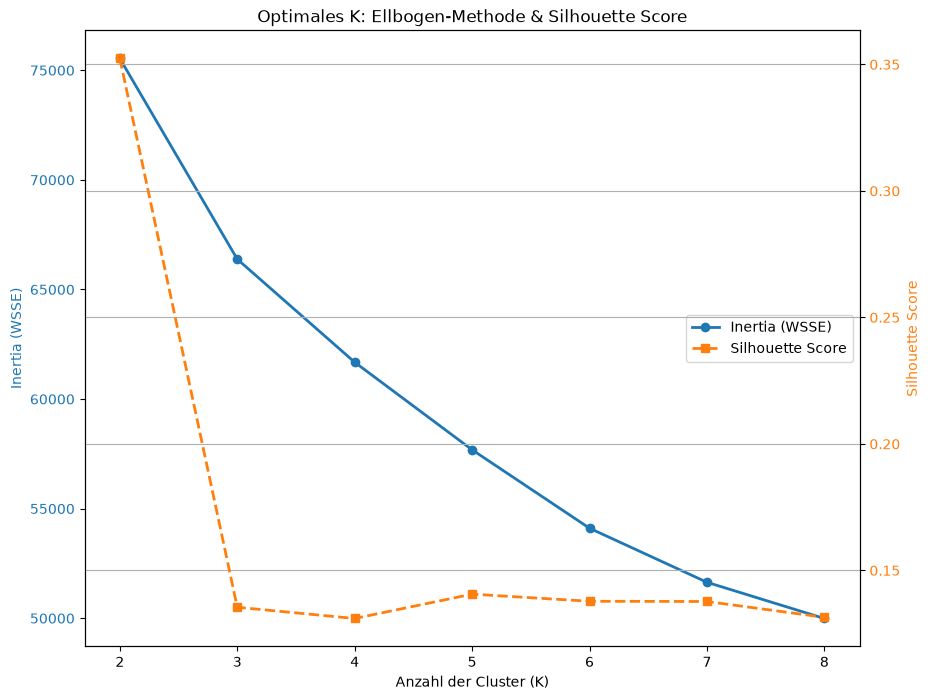

Grafik erfolgreich mit Legende in '../reports/figures/elbow_silhouette_plot.png' gespeichert!


In [6]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Daten laden
df_scaled = pd.read_csv('../data/traveltide_features_scaled.csv')
df_unscaled = pd.read_csv('../data/traveltide_features_unscaled.csv')

# Features für das Modell isolieren (ohne user_id)
X = df_scaled.drop(columns=['user_id'])

# 2. Ellbogen-Methode & Silhouette Score berechnen (für K von 2 bis 8)
inertia = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X, kmeans.labels_))

# 3. Ordnerstruktur für Abbildungen sicherstellen
os.makedirs('../reports/figures', exist_ok=True)

# 4. Ergebnisse visualisieren
fig, ax1 = plt.subplots(figsize=(10, 8))

# Linke Y-Achse: Inertia (Blau)
color_inertia = 'tab:blue'
ax1.set_xlabel('Anzahl der Cluster (K)')
ax1.set_ylabel('Inertia (WSSE)', color=color_inertia)
line1 = ax1.plot(k_range, inertia, marker='o', color=color_inertia, linewidth=2, label='Inertia (WSSE)')
ax1.tick_params(axis='y', labelcolor=color_inertia)

# Rechte Y-Achse: Silhouette Score (Orange)
ax2 = ax1.twinx()
color_sil = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color_sil)
line2 = ax2.plot(k_range, silhouette_scores, marker='s', linestyle='--', color=color_sil, linewidth=2, label='Silhouette Score')
ax2.tick_params(axis='y', labelcolor=color_sil)

# Beiderseitige Legende zusammenführen und anzeigen
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right')

plt.title('Optimales K: Ellbogen-Methode & Silhouette Score')
plt.grid(True)

# Grafik im Ordner reports/figures speichern
plt.savefig('../reports/figures/elbow_silhouette_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Grafik erfolgreich mit Legende in '../reports/figures/elbow_silhouette_plot.png' gespeichert!")

In [7]:
# 1. K-Means Modell mit K=5 trainieren
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)

# 2. Cluster-Labels berechnen und an unskalierten Datensatz anfügen
df_unscaled['cluster'] = kmeans.fit_predict(X)

# 3. Nutzerverteilung auf die Cluster anzeigen
print("Nutzerverteilung pro Cluster:")
print(df_unscaled['cluster'].value_counts().sort_index())

# 4. Mittelwerte pro Cluster berechnen (Cluster-Profilierung)
cluster_profile = df_unscaled.groupby('cluster').mean(numeric_only=True)

# Transponiert zur besseren Übersicht darstellen
cluster_profile.T

Nutzerverteilung pro Cluster:
cluster
0     558
1    2032
2    2313
3     536
4     559
Name: count, dtype: int64


cluster,0,1,2,3,4
user_id,554022.974910,541584.653543,548422.718980,541479.811567,542349.781753
married,0.390681,0.442913,0.463467,0.416045,0.409660
has_children,0.336918,0.257874,0.378297,0.333955,0.343470
total_sessions,8.179211,8.240157,8.188932,8.270522,8.101968
total_page_clicks,94.103943,148.291831,114.988327,320.875000,131.960644
avg_session_duration_sec,93.150741,134.599372,106.234083,897.598962,124.635530
avg_flight_discount,0.106686,0.106810,0.111841,0.107845,0.112472
avg_hotel_discount,0.074219,0.072350,0.076845,0.072777,0.076185
total_cancellations,0.023297,0.006398,0.009944,1.027985,0.017889
total_flights_booked,0.202509,3.676673,1.446174,2.667910,2.429338


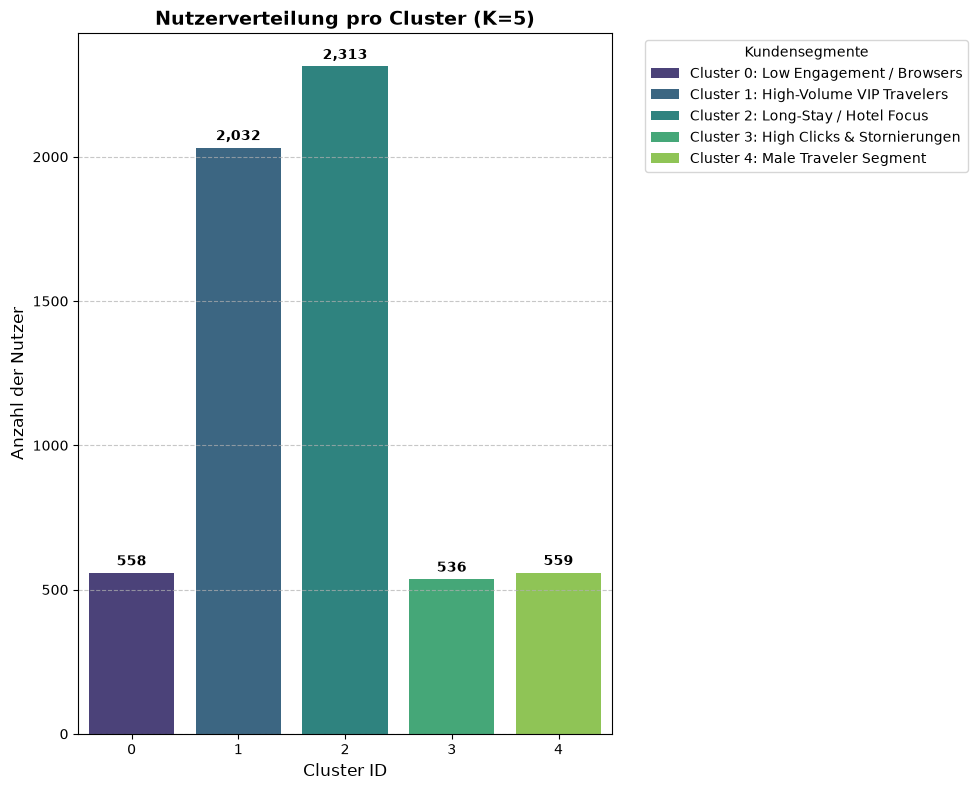

Aktualisierte Grafik inklusive Legende unter '../reports/figures/cluster_distribution.png' gespeichert!


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dataframe für Plot aufbauen
cluster_counts = df_unscaled['cluster'].value_counts().sort_index().reset_index()
cluster_counts.columns = ['cluster', 'count']

# Mapping für Business-Labels/Personas
persona_labels = {
    0: 'Cluster 0: Low Engagement / Browsers',
    1: 'Cluster 1: High-Volume VIP Travelers',
    2: 'Cluster 2: Long-Stay / Hotel Focus',
    3: 'Cluster 3: High Clicks & Stornierungen',
    4: 'Cluster 4: Male Traveler Segment'
}
cluster_counts['persona'] = cluster_counts['cluster'].map(persona_labels)

# Visualisierung erstellen
plt.figure(figsize=(10, 8))
ax = sns.barplot(
    data=cluster_counts,
    x='cluster',
    y='count',
    hue='persona',
    dodge=False,
    palette='viridis'
)

plt.title('Nutzerverteilung pro Cluster (K=5)', fontsize=14, fontweight='bold')
plt.xlabel('Cluster ID', fontsize=12)
plt.ylabel('Anzahl der Nutzer', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Legende hinzufügen
plt.legend(title='Kundensegmente', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# Zahlen über den Balken einblenden
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height):,}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', xytext=(0, 8), 
                    textcoords='offset points', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/cluster_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("Aktualisierte Grafik inklusive Legende unter '../reports/figures/cluster_distribution.png' gespeichert!")

In [11]:
# 1. Perks basierend auf Cluster-Eigenschaften definieren
perk_mapping = {
    0: 'Exclusive Discounts / High-Incentive Promo', # Reaktivierung für inaktive Nutzer
    1: 'Free Checked Bag',                           # Vielflieger-Vorteil für High-Volume VIPs
    2: 'Free Hotel Night / Late Check-Out',         # Belohnung für Langzeit-Hotelbucher
    3: 'No Cancellation Fee / Flexible Booking',     # Risikominimierung für Buchungsabbrecher
    4: 'Free Flight Upgrade / Priority Pass'         # Business & Solo Travel Perks
}

# 2. Perks und Persona-Namen im Datensatz ergänzen
df_unscaled['segment_name'] = df_unscaled['cluster'].map(persona_labels)
df_unscaled['assigned_perk'] = df_unscaled['cluster'].map(perk_mapping)

# 3. Finalen Datensatz für das Marketing-Team speichern
df_unscaled.to_csv('../data/traveltide_final_segments.csv', index=False)

# Vorschau der Ergebnisse
print("--- SEGMENTIERUNG & PERK-ZUWEISUNG ERFOLGREICH ---")
print("Gespeichert in: 'data/traveltide_final_segments.csv'\n")
df_unscaled[['user_id', 'cluster', 'segment_name', 'assigned_perk']].head(10)

--- SEGMENTIERUNG & PERK-ZUWEISUNG ERFOLGREICH ---
Gespeichert in: 'data/traveltide_final_segments.csv'



,user_id,cluster,segment_name,assigned_perk
0,23557,2,Cluster 2: Long-Stay / Hotel Focus,Free Hotel Night / Late Check-Out
1,94883,2,Cluster 2: Long-Stay / Hotel Focus,Free Hotel Night / Late Check-Out
2,101486,2,Cluster 2: Long-Stay / Hotel Focus,Free Hotel Night / Late Check-Out
3,101961,1,Cluster 1: High-Volume VIP Travelers,Free Checked Bag
4,106907,3,Cluster 3: High Clicks & Stornierungen,No Cancellation Fee / Flexible Booking
5,118043,1,Cluster 1: High-Volume VIP Travelers,Free Checked Bag
6,120851,2,Cluster 2: Long-Stay / Hotel Focus,Free Hotel Night / Late Check-Out
7,125845,1,Cluster 1: High-Volume VIP Travelers,Free Checked Bag
8,133058,0,Cluster 0: Low Engagement / Browsers,Exclusive Discounts / High-Incentive Promo
9,149058,1,Cluster 1: High-Volume VIP Travelers,Free Checked Bag


# Executive Summary: TravelTide Loyalty Program Segmentation

**Projekt:** TravelTide Customer Segmentation & Rewards Strategy  
**Datengrundlage:** 5.998 aktive Nutzer (Session-Aktivität > 7 seit 04.01.2023)  
**Methode:** K-Means Clustering ($K=5$) auf standardisierten Verhaltens- und Demografie-Features  

---

## **1. Kern-Erkenntnisse der Segmentierung**

* **Segment 0 – Low Engagement / Browsers (558 Nutzer):** Zeigen minimale Buchungsaktivität trotz Plattform-Nutzung.
* **Segment 1 – High-Volume VIP Travelers (2.032 Nutzer):** Unsere aktivsten Kunden mit der höchsten Flug- ($3{,}68$) und Hotel-Buchungsrate ($3{,}65$).
* **Segment 2 – Long-Stay / Hotel Focus (2.313 Nutzer):** Das größte Segment; zeichnet sich durch überdurchschnittlich lange Hotelaufenthalte ($>4$ Nächte) aus.
* **Segment 3 – High Clicks & Stornierungen (536 Nutzer):** Sehr hohe Interaktionszeit, zeigt jedoch Unsicherheiten und hohe Stornierungsraten ($1{,}03$).
* **Segment 4 – Male Traveler Segment (559 Nutzer):** Reines Männer-Segment mit stabilen, ausgewogenen Buchungsmustern.

---

## **2. Strategische Perk-Zuweisung**

| Cluster | Segment-Name | Anzahl Nutzer | Zugeordneter Perk |
| :--- | :--- | :--- | :--- |
| **0** | Low Engagement / Browsers | 558 | **Exclusive Discounts / Promo-Gutscheine** |
| **1** | High-Volume VIP Travelers | 2.032 | **Free Checked Bag** |
| **2** | Long-Stay / Hotel Focus | 2.313 | **Free Hotel Night / Late Check-Out** |
| **3** | High Clicks & Stornierungen | 536 | **No Cancellation Fee / Flexible Booking** |
| **4** | Male Traveler Segment | 559 | **Free Flight Upgrade / Priority Pass** |

---

## **3. Nächste Schritte & Empfehlungen**

1. **A/B-Testing im Marketing:** Testen der zugewiesenen Perks gegen eine Kontrollgruppe ohne Belohnung, um den Net Incremental Value (NIV) zu messen.
2. **Daten-Pipeline Automatisierung:** Integration des Clustering-Skripts in die monatliche ETL-Strecke zur dynamischen Re-Klassifizierung neuer Nutzer.